<a href="https://colab.research.google.com/github/fiannnn9090/tmdb-movie-analytics/blob/main/tmdb_movie_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import ast
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 110

os.makedirs('images', exist_ok=True)

# ---------- Load data ----------
# Dataset: TMDB 5000 Movie Dataset (Kaggle), file tmdb_5000_movies.csv
DATA_PATH = 'tmdb_5000_movies.csv'
if not os.path.exists(DATA_PATH):
    from google.colab import files
    print('Upload tmdb_5000_movies.csv')
    files.upload()

df = pd.read_csv(DATA_PATH)

print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
print(df.columns.tolist())
df.info()

Rows: 4,803 | Columns: 20
['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companie

In [7]:
df_clean = df.copy()

df_clean[['budget', 'revenue', 'runtime']] = (
    df_clean[['budget', 'revenue', 'runtime']].replace(0, np.nan)
)
df_clean.loc[df_clean['vote_count'] == 0, 'vote_average'] = np.nan

df_clean['release_date'] = pd.to_datetime(df_clean['release_date'], errors='coerce')
df_clean['release_year'] = df_clean['release_date'].dt.year.astype('Int64')
df_clean['release_month'] = df_clean['release_date'].dt.month.astype('Int64')

def parse_genres(value):
    try:
        return [g['name'] for g in ast.literal_eval(value)]
    except (ValueError, SyntaxError, TypeError):
        return []

df_clean['genre_list'] = df_clean['genres'].apply(parse_genres)
df_clean['primary_genre'] = df_clean['genre_list'].apply(lambda g: g[0] if g else 'Unknown')

MIN_BUDGET = 10_000    # budget di bawah ini dicurigai salah input
MIN_REVENUE = 10_000   # revenue di bawah ini dicurigai salah satuan/input

df_clean['valid_financial'] = (
    (df_clean['budget'] >= MIN_BUDGET) & (df_clean['revenue'] >= MIN_REVENUE)
)
df_clean['profit'] = (df_clean['revenue'] - df_clean['budget']).where(df_clean['valid_financial'])
df_clean['roi'] = (df_clean['profit'] / df_clean['budget']).where(df_clean['valid_financial'])
df_clean['revenue_multiple'] = (df_clean['revenue'] / df_clean['budget']).where(df_clean['valid_financial'])

In [8]:
print(f"Total film           : {len(df_clean):,}")
print(f"Data finansial valid : {df_clean['valid_financial'].sum():,}")

display(
    df_clean.loc[df_clean['valid_financial'], ['budget', 'revenue', 'profit', 'roi']].describe()
)

Total film           : 4,803
Data finansial valid : 3,205


,budget,revenue,profit,roi
count,"3,205.00","3,205.00","3,205.00","3,205.00"
mean,"40,927,640.11","122,144,438.62","81,216,798.50",10.12
std,"44,445,206.84","186,706,526.70","158,570,103.05",240.29
min,"10,000.00","10,000.00","-165,710,090.00",-1.00
25%,"11,000,000.00","17,436,509.00","345,188.00",0.03
50%,"25,500,000.00","56,298,474.00","27,105,395.00",1.30
75%,"55,000,000.00","147,780,440.00","98,018,522.00",3.42
max,"380,000,000.00","2,787,965,087.00","2,550,965,087.00","12,889.39"


In [9]:
fin = df_clean[df_clean['valid_financial']].copy()
cols = ['title', 'release_year', 'budget', 'revenue', 'profit', 'roi']

print(f"Film untung (profit > 0): {(fin['profit'] > 0).mean() * 100:.2f}%")
print("Revenue < 10.000  :", (fin['revenue'] < 10_000).sum())
print("Revenue < 100.000 :", (fin['revenue'] < 100_000).sum())

print("\n10 revenue terendah")
display(fin.nsmallest(10, 'revenue')[cols])

print("\n10 ROI tertinggi")
display(fin.nlargest(10, 'roi')[cols])

Film untung (profit > 0): 75.79%
Revenue < 10.000  : 0
Revenue < 100.000 : 35

10 revenue terendah


,title,release_year,budget,revenue,profit,roi
4772,Down Terrace,2009,"31,192.00","10,000.00","-21,192.00",-0.68
4397,Alone With Her,2006,"1,000,000.00","10,018.00","-989,982.00",-0.99
4486,Naturally Native,1999,"700,000.00","10,508.00","-689,492.00",-0.98
3815,Major Dundee,1965,"3,800,000.00","14,873.00","-3,785,127.00",-1.00
3120,Strangerland,2015,"10,000,000.00","17,472.00","-9,982,528.00",-1.00
2901,5 Days of War,2011,"20,000,000.00","17,479.00","-19,982,521.00",-1.00
2651,The Good Night,2007,"15,000,000.00","20,380.00","-14,979,620.00",-1.00
3956,The Divide,2011,"3,000,000.00","22,000.00","-2,978,000.00",-0.99
2650,All The Queen's Men,2001,"15,000,000.00","23,000.00","-14,977,000.00",-1.00
4306,"Pink Ribbons, Inc.",2011,"900,000.00","25,000.00","-875,000.00",-0.97



10 ROI tertinggi


,title,release_year,budget,revenue,profit,roi
4577,Paranormal Activity,2007,"15,000.00","193,355,800.00","193,340,800.00","12,889.39"
4496,The Blair Witch Project,1999,"60,000.00","248,000,000.00","247,940,000.00","4,132.33"
4724,Eraserhead,1977,"10,000.00","7,000,000.00","6,990,000.00",699.00
4788,Pink Flamingos,1972,"12,000.00","6,000,000.00","5,988,000.00",499.00
4742,Super Size Me,2004,"65,000.00","28,575,078.00","28,510,078.00",438.62
4723,The Gallows,2015,"100,000.00","42,664,410.00","42,564,410.00",425.64
4514,Open Water,2004,"130,000.00","54,667,954.00","54,537,954.00",419.52
3159,The Texas Chain Saw Massacre,1974,"85,000.00","30,859,000.00","30,774,000.00",362.05
4441,Bambi,1942,"858,000.00","267,447,150.00","266,589,150.00",310.71
4668,The Stewardesses,1969,"100,000.00","27,000,000.00","26,900,000.00",269.00


In [10]:
fin = df_clean[df_clean['valid_financial']].copy()

# Revenue sangat kecil padahal budget >= 1 juta
suspect = fin[(fin['revenue'] < 100_000) & (fin['budget'] >= 1_000_000)]
print("Masih mencurigakan:", len(suspect))
display(suspect[['title', 'release_year', 'budget', 'revenue', 'roi']])

print(f"\nFilm finansial valid : {len(fin):,}")
print(f"Film untung          : {(fin['profit'] > 0).mean() * 100:.2f}%")
print(f"Median ROI           : {fin['roi'].median():.2f}")
print(f"Mean ROI             : {fin['roi'].mean():.2f}")

Masih mencurigakan: 23


,title,release_year,budget,revenue,roi
1101,Foodfight!,2012,"65,000,000.00","73,706.00",-1.00
2646,Silent Trigger,1996,"15,000,000.00","76,382.00",-0.99
2650,All The Queen's Men,2001,"15,000,000.00","23,000.00",-1.00
2651,The Good Night,2007,"15,000,000.00","20,380.00",-1.00
2714,Margaret,2011,"14,000,000.00","46,495.00",-1.00
2901,5 Days of War,2011,"20,000,000.00","17,479.00",-1.00
3115,"An Alan Smithee Film: Burn, Hollywood, Burn",1998,"10,000,000.00","45,779.00",-1.00
3120,Strangerland,2015,"10,000,000.00","17,472.00",-1.00
3295,Aloft,2014,"8,000,000.00","53,086.00",-0.99
3397,Ca$h,2010,"7,000,000.00","46,488.00",-0.99



Film finansial valid : 3,205
Film untung          : 75.79%
Median ROI           : 1.30
Mean ROI             : 10.12


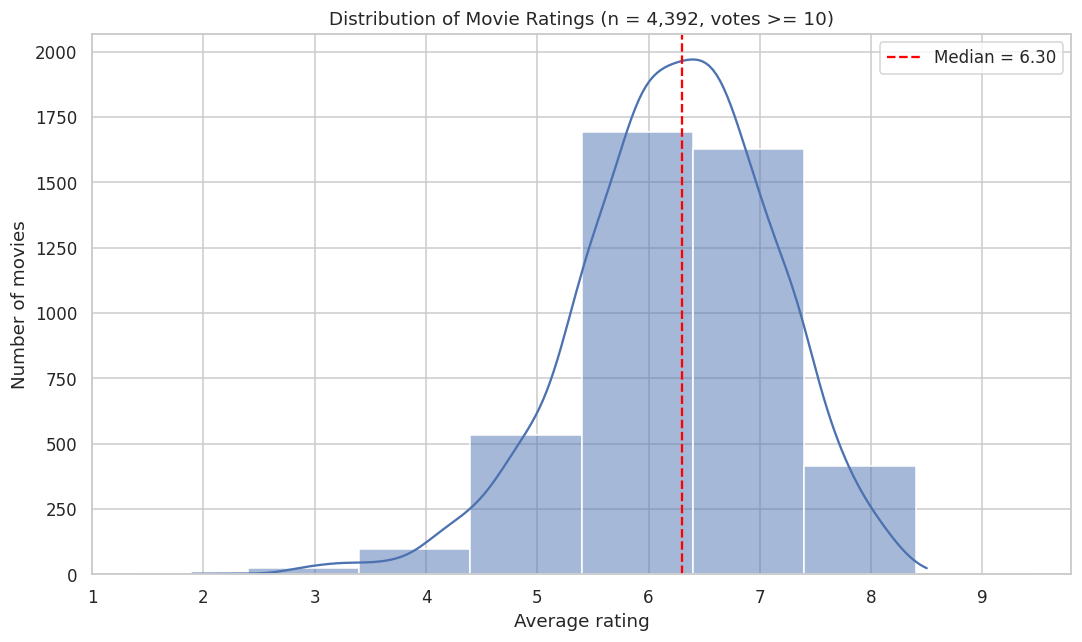

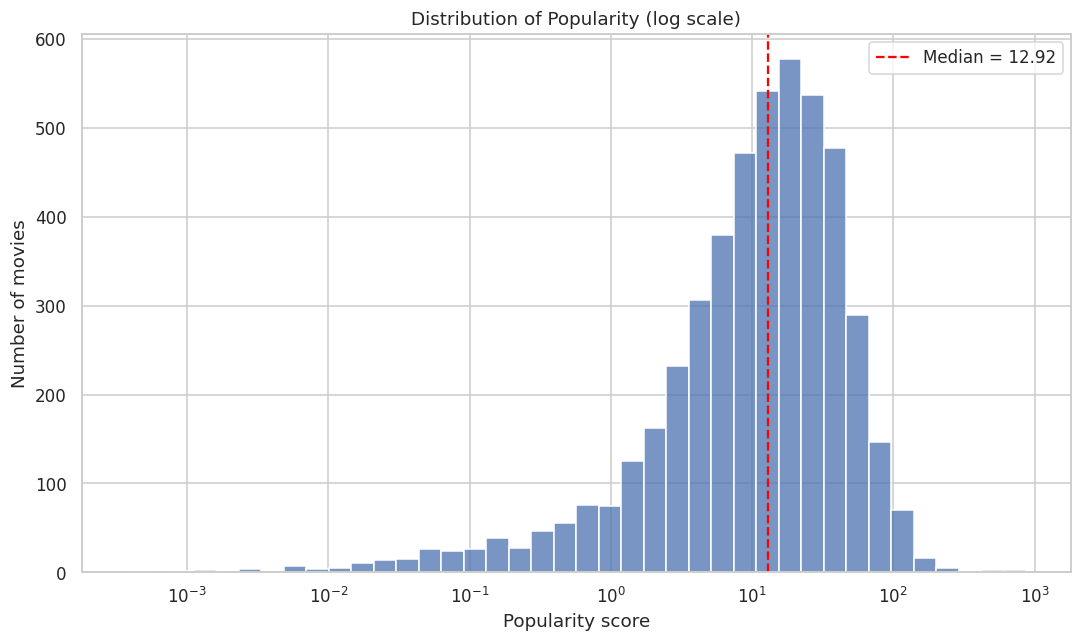

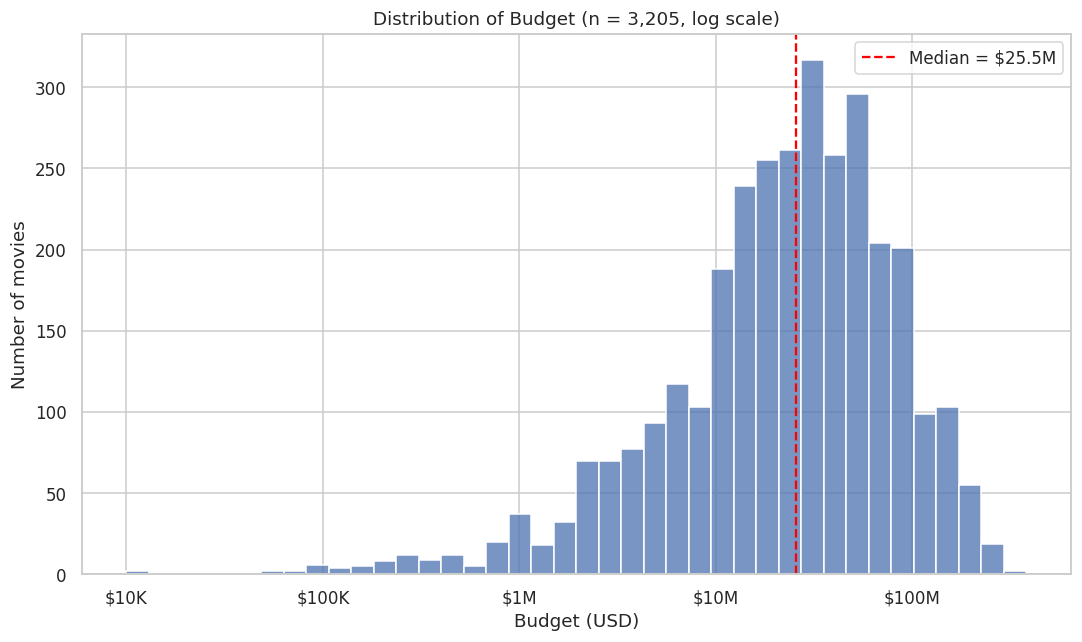

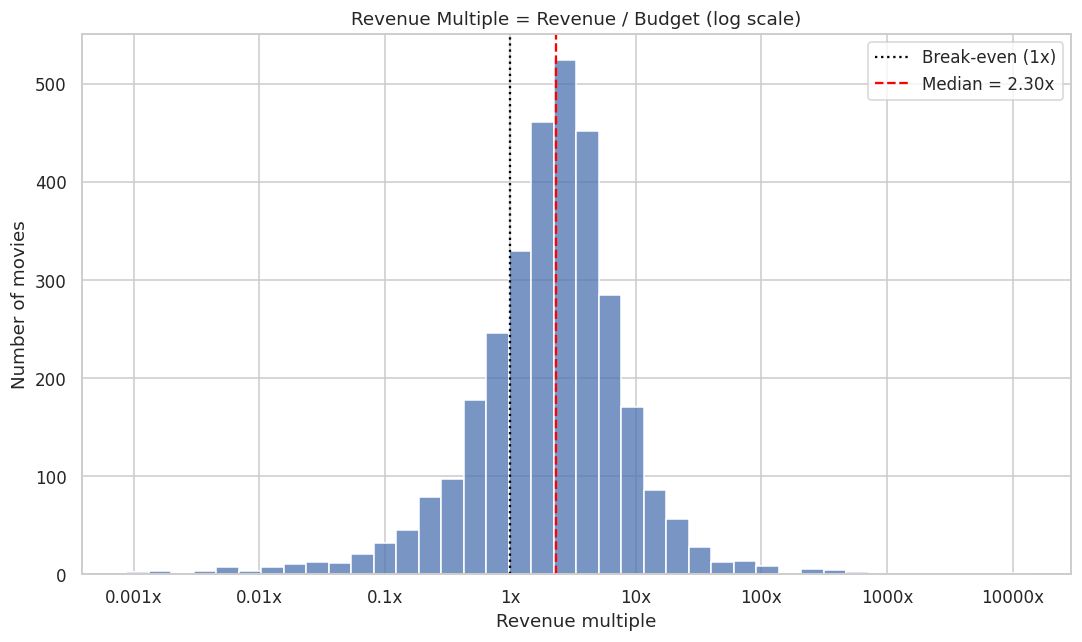

count   4,392.00
mean        6.23
std         0.89
min         1.90
25%         5.70
50%         6.30
75%         6.80
max         8.50
Name: vote_average, dtype: float64

Popularity  mean=21.50 median=12.92 max=875.58
Budget      mean=$40.9M median=$25.5M
Rev multiple median=2.30x | di bawah 1x: 24.2%

Film 'tidak biasa' (revenue < $100K, budget >= $1M): 23
Semua film      n=3,205 | untung=75.79% | median multiple=2.30x
Tanpa film tsb  n=3,182 | untung=76.34% | median multiple=2.32x


In [11]:
from matplotlib.ticker import FuncFormatter

MIN_VOTES = 10   # rating dari < 10 vote kurang bisa dipercaya

# Helper
def save_show(name):
    plt.tight_layout()
    plt.savefig(f'images/{name}.png', dpi=200, bbox_inches='tight')  # simpan SEBELUM show
    plt.show()

def usd(x, _):
    if x >= 1e9: return f'${x/1e9:g}B'
    if x >= 1e6: return f'${x/1e6:g}M'
    if x >= 1e3: return f'${x/1e3:g}K'
    return f'${x:g}'

# Subset data
rated = df_clean[df_clean['vote_count'] >= MIN_VOTES]
fin = df_clean[df_clean['valid_financial']]
pop = df_clean.loc[df_clean['popularity'] > 0, 'popularity']

# 1) Rating (data diskret, kelipatan 0,1)
med = rated['vote_average'].median()
plt.figure()
sns.histplot(rated['vote_average'].round(1), discrete=True, kde=True)
plt.axvline(med, linestyle='--', color='red', label=f'Median = {med:.2f}')
plt.title(f'Distribution of Movie Ratings (n = {len(rated):,}, votes >= {MIN_VOTES})')
plt.xlabel('Average rating')
plt.ylabel('Number of movies')
plt.legend()
save_show('01_rating_distribution')

# 2) Popularity (skala log karena sangat miring)
med = pop.median()
plt.figure()
sns.histplot(pop, bins=40, log_scale=True)
plt.axvline(med, linestyle='--', color='red', label=f'Median = {med:.2f}')
plt.title('Distribution of Popularity (log scale)')
plt.xlabel('Popularity score')
plt.ylabel('Number of movies')
plt.legend()
save_show('02_popularity_distribution')

# 3) Budget (skala log, label dalam USD)
med = fin['budget'].median()
plt.figure()
sns.histplot(fin['budget'], bins=40, log_scale=True)
plt.axvline(med, linestyle='--', color='red', label=f'Median = ${med/1e6:.1f}M')
plt.gca().xaxis.set_major_formatter(FuncFormatter(usd))
plt.title(f'Distribution of Budget (n = {len(fin):,}, log scale)')
plt.xlabel('Budget (USD)')
plt.ylabel('Number of movies')
plt.legend()
save_show('03_budget_distribution')

# 4) Revenue multiple (1x = impas, skala log)
med = fin['revenue_multiple'].median()
plt.figure()
sns.histplot(fin['revenue_multiple'], bins=40, log_scale=True)
plt.axvline(1, linestyle=':', color='black', label='Break-even (1x)')
plt.axvline(med, linestyle='--', color='red', label=f'Median = {med:.2f}x')
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:g}x'))
plt.title('Revenue Multiple = Revenue / Budget (log scale)')
plt.xlabel('Revenue multiple')
plt.ylabel('Number of movies')
plt.legend()
save_show('04_revenue_multiple_distribution')

# Ringkasan angka
print(rated['vote_average'].describe().round(2))
print(f"\nPopularity  mean={pop.mean():.2f} median={pop.median():.2f} max={pop.max():.2f}")
print(f"Budget      mean=${fin['budget'].mean()/1e6:.1f}M median=${fin['budget'].median()/1e6:.1f}M")
print(f"Rev multiple median={fin['revenue_multiple'].median():.2f}x | "
      f"di bawah 1x: {(fin['revenue_multiple'] < 1).mean()*100:.1f}%")

# Pengecekan ketahanan: apakah 23 film "tidak biasa" memengaruhi hasil?
mask = (fin['revenue'] < 100_000) & (fin['budget'] >= 1_000_000)
print(f"\nFilm 'tidak biasa' (revenue < $100K, budget >= $1M): {mask.sum()}")
for label, d in [('Semua film', fin), ('Tanpa film tsb', fin[~mask])]:
    print(f"{label:15s} n={len(d):,} | untung={(d['profit'] > 0).mean()*100:.2f}% "
          f"| median multiple={d['revenue_multiple'].median():.2f}x")

### Univariate Findings

- **Ratings are centered and roughly symmetric.** Among films with at least 10 votes
  (n = 4,392), the median rating is 6.30 and half of the films fall between 5.70 and 6.80.
  Ratings below 4 or above 8 are rare.
- **Popularity is highly right-skewed.** The mean (21.50) is well above the median (12.92),
  and the maximum reaches 875.58. On a log scale the distribution is roughly bell-shaped,
  so a few titles are far more popular than the typical film.
- **Budgets are concentrated in the mid-range.** Among 3,205 films with valid financial data,
  the median budget is $25.5M versus a mean of $40.9M. Most budgets lie between roughly
  $10M and $100M, with a thin tail of low-budget films.
- **Typical return is positive, but risk is wide.** The median revenue multiple is 2.30x,
  yet 24.2% of films earned less than their budget. Both tails are long: near-total losses
  on one side and rare multiples above 100x on the other.

> Median is used instead of mean wherever the distribution is skewed.

> **Robustness check:** Excluding 23 films with unusually low revenue (< $100K) despite budgets of $1M or more
> changes the profit rate from 75.79% to 76.34% and the median revenue multiple from 2.30x to 2.32x.
> The conclusions do not depend on these films, so they are retained.

Spearman budget vs revenue (absolut)    : 0.674
Spearman budget vs revenue multiple     : -0.136


,films,min_budget_M,max_budget_M,median_multiple,median_profit_M,profit_rate_pct
budget_group,,,,,,
Q1 (lowest),827,0.01,11.00,3.57,8.54,76.66
Q2,776,11.50,25.50,2.04,18.52,70.10
Q3,817,25.53,55.00,2.10,39.70,74.79
Q4 (highest),785,56.00,380.00,2.22,112.31,81.53


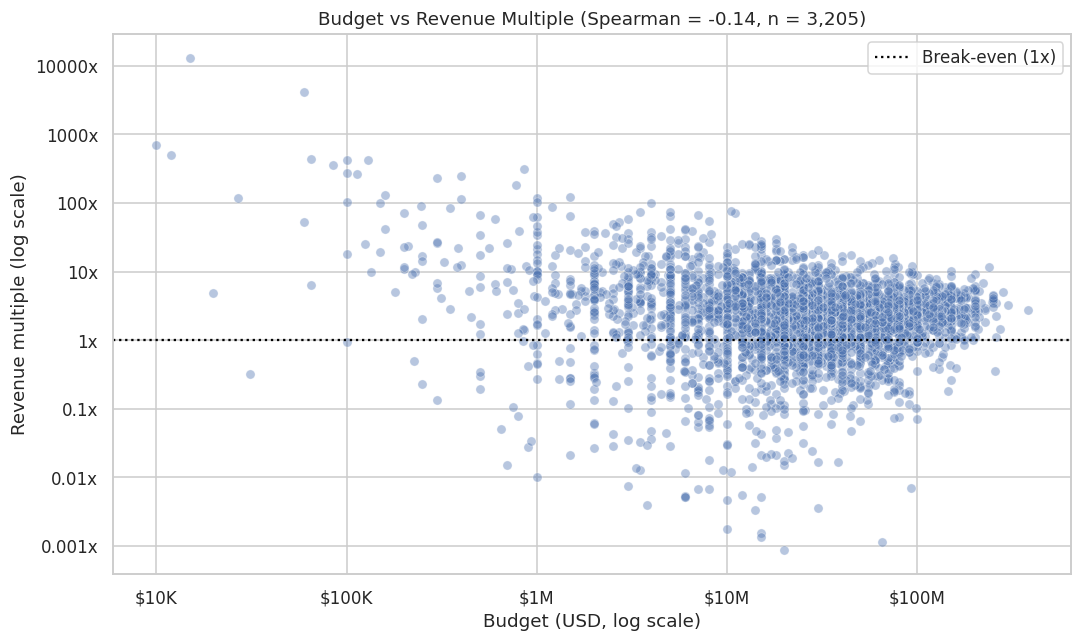

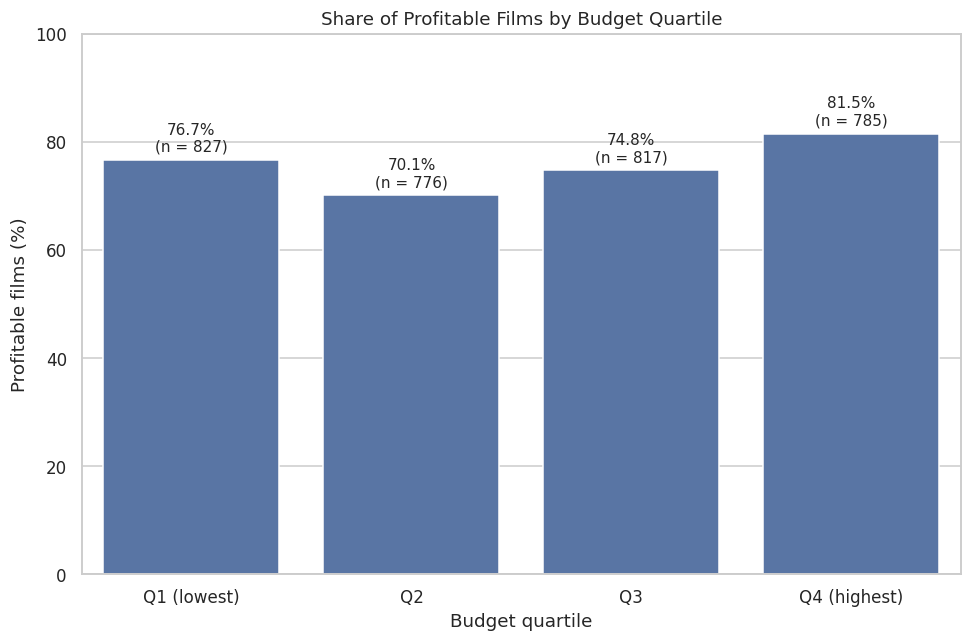

In [12]:
fin = df_clean[df_clean['valid_financial']].copy()

# 1) Korelasi berbasis peringkat (Spearman)
rho_multiple = fin['budget'].corr(fin['revenue_multiple'], method='spearman')
rho_revenue = fin['budget'].corr(fin['revenue'], method='spearman')
print(f"Spearman budget vs revenue (absolut)    : {rho_revenue:.3f}")
print(f"Spearman budget vs revenue multiple     : {rho_multiple:.3f}")

# 2) Kelompok budget (kuartil)
fin['budget_group'] = pd.qcut(
    fin['budget'], 4, labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)']
)

budget_summary = (
    fin.groupby('budget_group', observed=True)
    .agg(
        films=('title', 'count'),
        min_budget_M=('budget', lambda s: s.min() / 1e6),
        max_budget_M=('budget', lambda s: s.max() / 1e6),
        median_multiple=('revenue_multiple', 'median'),
        median_profit_M=('profit', lambda s: s.median() / 1e6),
        profit_rate_pct=('profit', lambda s: (s > 0).mean() * 100),
    )
    .round(2)
)
display(budget_summary)

# 3) Scatter: budget vs revenue multiple
plt.figure()
sns.scatterplot(data=fin, x='budget', y='revenue_multiple', alpha=0.4)
plt.xscale('log')
plt.yscale('log')
plt.axhline(1, linestyle=':', color='black', label='Break-even (1x)')
plt.gca().xaxis.set_major_formatter(FuncFormatter(usd))
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:g}x'))
plt.title(f'Budget vs Revenue Multiple (Spearman = {rho_multiple:.2f}, n = {len(fin):,})')
plt.xlabel('Budget (USD, log scale)')
plt.ylabel('Revenue multiple (log scale)')
plt.legend()
save_show('05_budget_vs_multiple')

# 4) Bar: persentase film untung per kelompok budget
plot_df = budget_summary.reset_index()
plt.figure(figsize=(9, 6))
ax = sns.barplot(data=plot_df, x='budget_group', y='profit_rate_pct')
for i, row in plot_df.iterrows():
    ax.text(i, row['profit_rate_pct'] + 1, f"{row['profit_rate_pct']:.1f}%\n(n = {int(row['films'])})",
            ha='center', va='bottom', fontsize=10)
plt.ylim(0, 100)
plt.title('Share of Profitable Films by Budget Quartile')
plt.xlabel('Budget quartile')
plt.ylabel('Profitable films (%)')
save_show('06_profit_rate_by_budget_group')

### Budget vs Return

- **Budget buys scale, not efficiency.** Budget is strongly associated with absolute revenue
  (Spearman = 0.67) but weakly and negatively associated with revenue multiple (Spearman = -0.14).
- **Median profit grows with budget**, from $8.5M in the lowest quartile (budgets under $11M)
  to $112.3M in the highest ($56M and above), while the median revenue multiple does not:
  3.57x in the lowest quartile versus 2.22x in the highest.
- **The relationship is not linear.** The median multiple drops from Q1 to Q2 (3.57x to 2.04x)
  and then stays roughly flat (2.10x in Q3, 2.22x in Q4).
- **Loss risk is lowest among the biggest budgets.** 81.5% of films in the highest budget
  quartile were profitable, compared with 70.1% in Q2 and 76.7% in Q1.

> These are descriptive associations. Films with very small budgets that have recorded revenue
> may be those that reached distribution, which could inflate the multiple in the lowest quartile.

Film finansial valid : 3,205
Baris film-genre     : 8,497  (satu film bisa masuk beberapa genre)
Genre yang dianalisis (>= 30 film): 18


,films,median_budget_M,median_multiple,median_profit_M,profit_rate_pct
genre,,,,,
Music,111,17.50,3.12,20.55,75.68
Horror,329,14.00,2.90,26.04,82.07
Animation,186,75.00,2.79,126.82,80.65
Documentary,37,2.50,2.73,6.55,70.27
Family,363,57.00,2.54,66.05,81.82
Romance,568,20.00,2.40,20.43,76.41
Adventure,659,60.00,2.39,65.56,79.51
Comedy,1100,25.00,2.32,27.53,76.64
Science Fiction,428,45.00,2.24,36.56,76.87


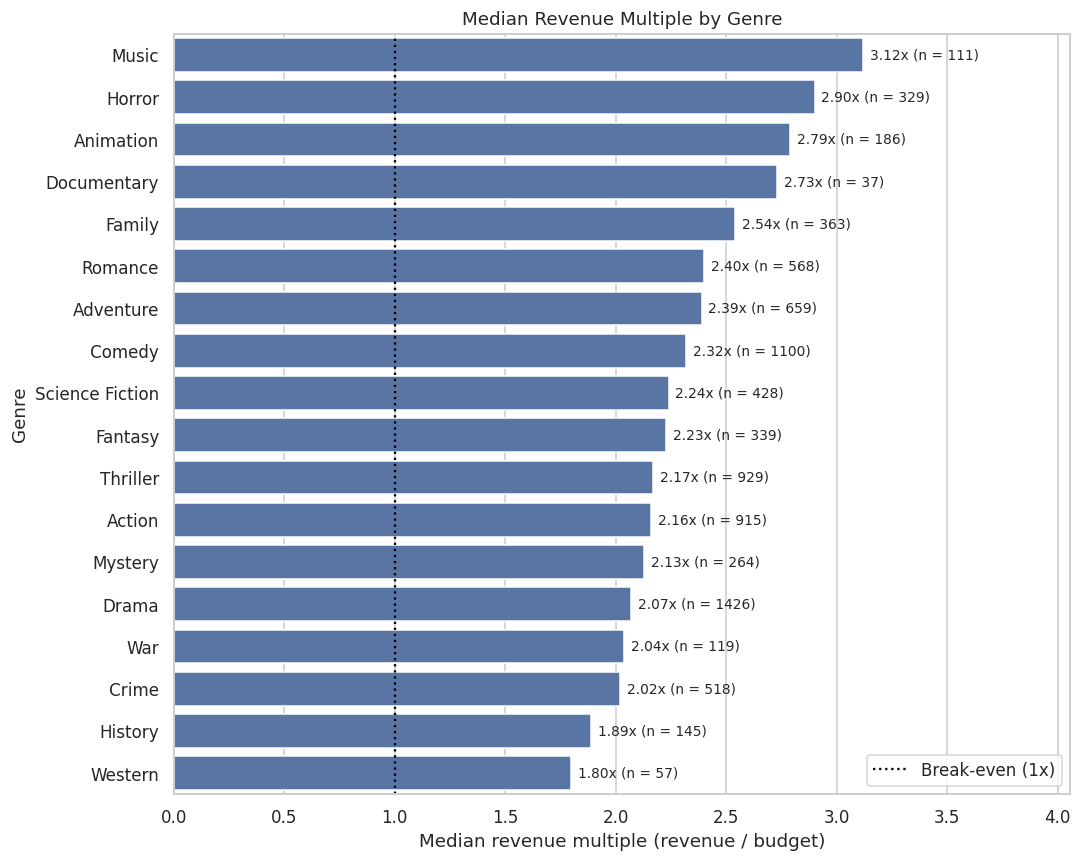

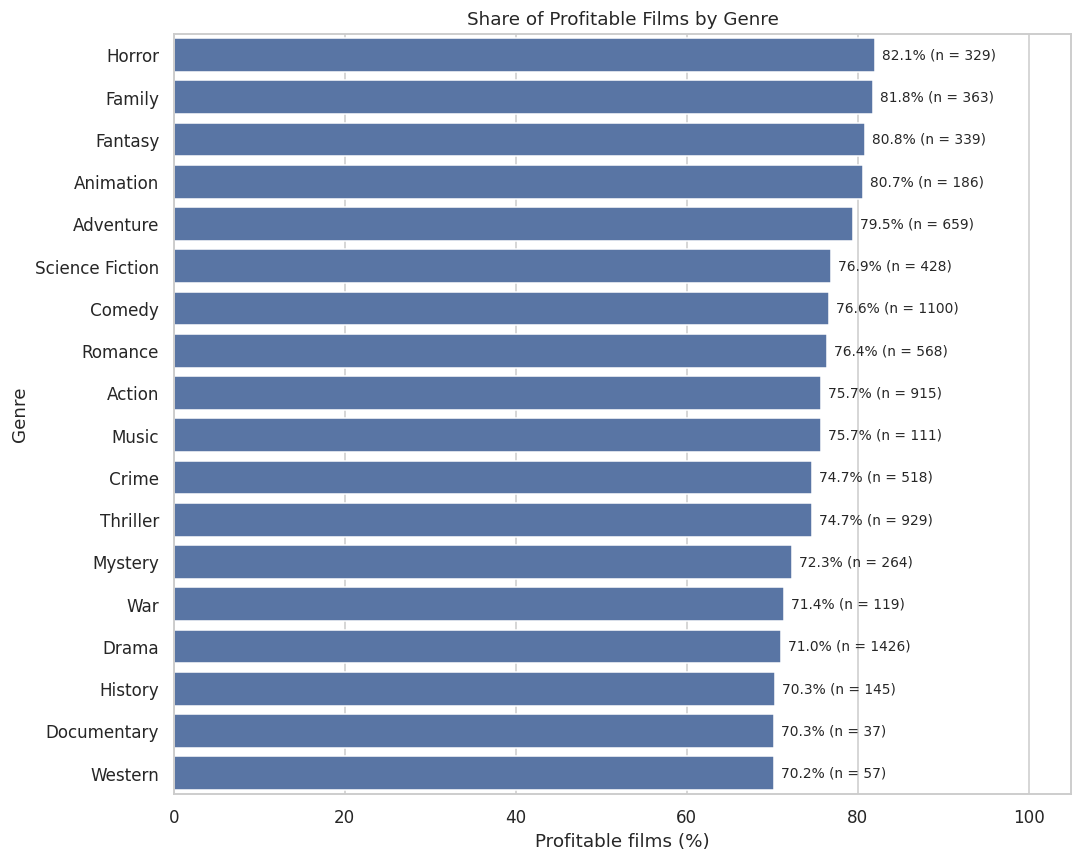

In [13]:
MIN_FILMS_PER_GENRE = 30

fin = df_clean[df_clean['valid_financial']].copy()

# 1) Satu baris per pasangan film-genre
genre_fin = (
    fin[['title', 'genre_list', 'budget', 'revenue', 'profit', 'revenue_multiple']]
    .explode('genre_list')
    .rename(columns={'genre_list': 'genre'})
    .dropna(subset=['genre'])
)

print(f"Film finansial valid : {len(fin):,}")
print(f"Baris film-genre     : {len(genre_fin):,}  (satu film bisa masuk beberapa genre)")

# 2) Ringkasan per genre
genre_summary = (
    genre_fin.groupby('genre')
    .agg(
        films=('title', 'count'),
        median_budget_M=('budget', lambda s: s.median() / 1e6),
        median_multiple=('revenue_multiple', 'median'),
        median_profit_M=('profit', lambda s: s.median() / 1e6),
        profit_rate_pct=('profit', lambda s: (s > 0).mean() * 100),
    )
    .round(2)
)
genre_summary = genre_summary[genre_summary['films'] >= MIN_FILMS_PER_GENRE]
genre_summary = genre_summary.sort_values('median_multiple', ascending=False)

print(f"Genre yang dianalisis (>= {MIN_FILMS_PER_GENRE} film): {len(genre_summary)}")
display(genre_summary)

# 3) Median revenue multiple per genre
plot_df = genre_summary.reset_index()          # sudah terurut menurun
plt.figure(figsize=(10, 8))
ax = sns.barplot(data=plot_df, x='median_multiple', y='genre', order=plot_df['genre'])
plt.axvline(1, linestyle=':', color='black', label='Break-even (1x)')
for i, row in plot_df.iterrows():
    ax.text(row['median_multiple'] + 0.03, i,
            f"{row['median_multiple']:.2f}x (n = {int(row['films'])})",
            va='center', fontsize=9)
plt.xlim(0, plot_df['median_multiple'].max() * 1.3)
plt.title('Median Revenue Multiple by Genre')
plt.xlabel('Median revenue multiple (revenue / budget)')
plt.ylabel('Genre')
plt.legend(loc='lower right')
save_show('07_multiple_by_genre')

# 4) Persentase film untung per genre
plot_df = genre_summary.sort_values('profit_rate_pct', ascending=False).reset_index()
plt.figure(figsize=(10, 8))
ax = sns.barplot(data=plot_df, x='profit_rate_pct', y='genre', order=plot_df['genre'])
for i, row in plot_df.iterrows():
    ax.text(row['profit_rate_pct'] + 0.8, i,
            f"{row['profit_rate_pct']:.1f}% (n = {int(row['films'])})",
            va='center', fontsize=9)
plt.xlim(0, 105)
plt.title('Share of Profitable Films by Genre')
plt.xlabel('Profitable films (%)')
plt.ylabel('Genre')
save_show('08_profit_rate_by_genre')

### Genre vs Return

- **Horror and Animation are two different routes to profit.** Horror combines a low median
  budget ($14M) with a 2.90x median revenue multiple and the highest profit rate (82.1%, n = 329).
  Animation has the largest median budget ($75M) and the highest median profit ($126.8M),
  with a 2.79x multiple and 80.7% of films profitable (n = 186).
- **Family, Fantasy and Adventure also show low loss risk** (79.5% to 81.8% profitable), but they
  are high-budget genres (median $57M to $60M), so genre and budget effects are intertwined.
- **Rankings depend on the metric.** Music has the highest median multiple (3.12x, n = 111) but
  only an average profit rate (75.7%), which may indicate more spread-out outcomes.
- **Drama, History and Western sit at the lower end.** Their median multiples are 2.07x, 1.89x
  and 1.80x, and about 70% to 71% of their films were profitable. Drama is the second largest
  genre in the sample (n = 1,426) with a median profit of only $15.3M.

> Genres overlap (a film can belong to several), so counts are not additive. Documentary (n = 37)
> and Western (n = 57) are small samples, and differences between mid-ranked genres are small,
> so they should not be read as a strict ranking.

Film dengan data finansial valid dan >= 10 vote: 3,166
Spearman rating vs revenue (absolut) : 0.122
Spearman rating vs revenue multiple  : 0.339


,films,median_revenue_M,median_multiple,median_profit_M,profit_rate_pct
rating_group,,,,,
< 5.0,176,23.70,1.03,0.45,51.14
5.0 - 5.9,831,56.31,1.77,19.18,68.59
6.0 - 6.9,1405,58.79,2.32,29.75,77.01
>= 7.0,754,75.89,3.96,47.46,89.39


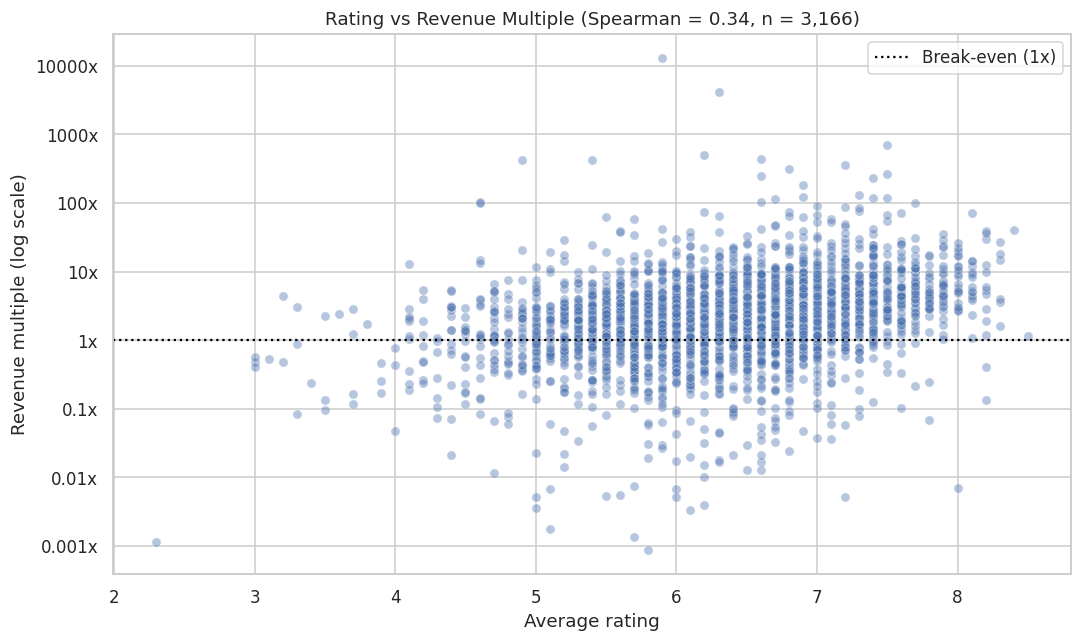

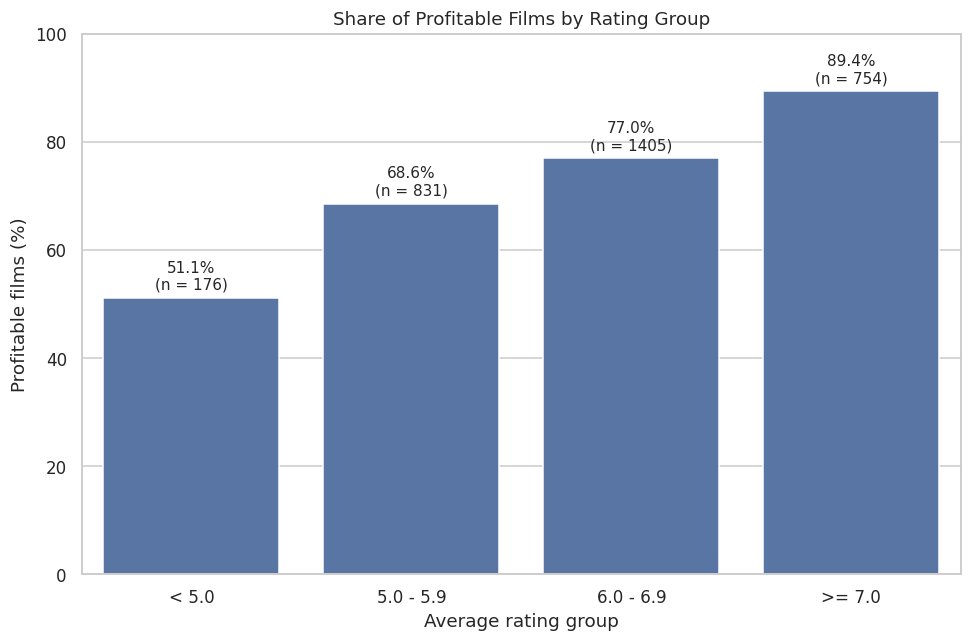

In [14]:
MIN_VOTES = 10

fin_r = df_clean[
    df_clean['valid_financial'] & (df_clean['vote_count'] >= MIN_VOTES)
].copy()
print(f"Film dengan data finansial valid dan >= {MIN_VOTES} vote: {len(fin_r):,}")

# ---------- 1) Korelasi berbasis peringkat (Spearman) ----------
rho_revenue = fin_r['vote_average'].corr(fin_r['revenue'], method='spearman')
rho_multiple = fin_r['vote_average'].corr(fin_r['revenue_multiple'], method='spearman')
print(f"Spearman rating vs revenue (absolut) : {rho_revenue:.3f}")
print(f"Spearman rating vs revenue multiple  : {rho_multiple:.3f}")

# ---------- 2) Kelompok rating ----------
fin_r['rating_group'] = pd.cut(
    fin_r['vote_average'],
    bins=[0, 5, 6, 7, 10],
    labels=['< 5.0', '5.0 - 5.9', '6.0 - 6.9', '>= 7.0'],
    right=False,
)

rating_summary = (
    fin_r.groupby('rating_group', observed=True)
    .agg(
        films=('title', 'count'),
        median_revenue_M=('revenue', lambda s: s.median() / 1e6),
        median_multiple=('revenue_multiple', 'median'),
        median_profit_M=('profit', lambda s: s.median() / 1e6),
        profit_rate_pct=('profit', lambda s: (s > 0).mean() * 100),
    )
    .round(2)
)
display(rating_summary)

# ---------- 3) Scatter: rating vs revenue multiple ----------
plt.figure()
sns.scatterplot(data=fin_r, x='vote_average', y='revenue_multiple', alpha=0.4)
plt.yscale('log')
plt.axhline(1, linestyle=':', color='black', label='Break-even (1x)')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:g}x'))
plt.title(f'Rating vs Revenue Multiple (Spearman = {rho_multiple:.2f}, n = {len(fin_r):,})')
plt.xlabel('Average rating')
plt.ylabel('Revenue multiple (log scale)')
plt.legend()
save_show('09_rating_vs_multiple')

# ---------- 4) Bar: persentase film untung per kelompok rating ----------
plot_df = rating_summary.reset_index()
plt.figure(figsize=(9, 6))
ax = sns.barplot(data=plot_df, x='rating_group', y='profit_rate_pct')
for i, row in plot_df.iterrows():
    ax.text(i, row['profit_rate_pct'] + 1,
            f"{row['profit_rate_pct']:.1f}%\n(n = {int(row['films'])})",
            ha='center', va='bottom', fontsize=10)
plt.ylim(0, 100)
plt.title('Share of Profitable Films by Rating Group')
plt.xlabel('Average rating group')
plt.ylabel('Profitable films (%)')
save_show('10_profit_rate_by_rating_group')

Film dianalisis: 3,166

Jumlah film per sel


rating_group,< 5.0,5.0 - 5.9,6.0 - 6.9,>= 7.0
budget_group,,,,
Q1 (lowest),37,143,353,263
Q2,60,199,354,179
Q3,43,239,352,159
Q4 (highest),36,250,346,153



Persentase film untung (%)


rating_group,< 5.0,5.0 - 5.9,6.0 - 6.9,>= 7.0
budget_group,,,,
Q1 (lowest),64.86,69.23,74.22,90.11
Q2,53.33,65.83,70.06,85.47
Q3,44.19,65.27,77.84,88.68
Q4 (highest),41.67,73.60,86.13,93.46



Median revenue multiple


rating_group,< 5.0,5.0 - 5.9,6.0 - 6.9,>= 7.0
budget_group,,,,
Q1 (lowest),2.13,2.09,3.30,5.23
Q2,1.10,1.75,1.93,3.40
Q3,0.74,1.77,2.08,3.22
Q4 (highest),0.79,1.72,2.52,3.82


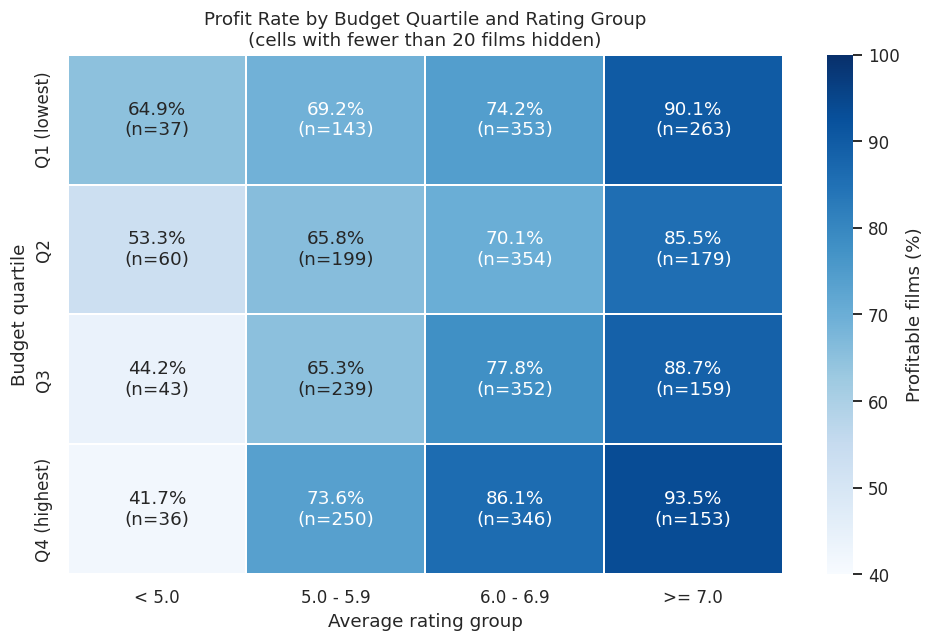

In [15]:
MIN_VOTES = 10
MIN_CELL = 20   # sel dengan film < ini dianggap tidak andal

fin_r = df_clean[
    df_clean['valid_financial'] & (df_clean['vote_count'] >= MIN_VOTES)
].copy()

fin_r['budget_group'] = pd.qcut(
    fin_r['budget'], 4, labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)']
)
fin_r['rating_group'] = pd.cut(
    fin_r['vote_average'],
    bins=[0, 5, 6, 7, 10],
    labels=['< 5.0', '5.0 - 5.9', '6.0 - 6.9', '>= 7.0'],
    right=False,
)

# ---------- 1) Ringkasan per kombinasi budget x rating ----------
cell_summary = (
    fin_r.groupby(['budget_group', 'rating_group'], observed=True)
    .agg(
        films=('title', 'count'),
        median_multiple=('revenue_multiple', 'median'),
        profit_rate_pct=('profit', lambda s: (s > 0).mean() * 100),
    )
    .round(2)
)

films_tbl = cell_summary['films'].unstack('rating_group').fillna(0).astype(int)
profit_tbl = cell_summary['profit_rate_pct'].unstack('rating_group')
multiple_tbl = cell_summary['median_multiple'].unstack('rating_group')

print(f"Film dianalisis: {len(fin_r):,}")
print("\nJumlah film per sel")
display(films_tbl)
print("\nPersentase film untung (%)")
display(profit_tbl)
print("\nMedian revenue multiple")
display(multiple_tbl)

# ---------- 2) Heatmap persentase film untung ----------
annot = profit_tbl.copy().astype(object)
for r in profit_tbl.index:
    for c in profit_tbl.columns:
        n = films_tbl.loc[r, c]
        annot.loc[r, c] = f"{profit_tbl.loc[r, c]:.1f}%\n(n={n})" if n > 0 else ""

mask = films_tbl < MIN_CELL

plt.figure(figsize=(9, 6))
sns.heatmap(
    profit_tbl.astype(float),
    annot=annot,
    fmt='',
    cmap='Blues',
    vmin=40,
    vmax=100,
    mask=mask,
    linewidths=1,
    cbar_kws={'label': 'Profitable films (%)'},
)
plt.title(f'Profit Rate by Budget Quartile and Rating Group\n(cells with fewer than {MIN_CELL} films hidden)')
plt.xlabel('Average rating group')
plt.ylabel('Budget quartile')
save_show('11_profit_rate_budget_x_rating')

### Rating vs Return

- **Rating is more closely related to efficiency than to scale.** Among 3,166 films with valid
  financial data and at least 10 votes, rating has a weak association with absolute revenue
  (Spearman = 0.12) and a moderate association with revenue multiple (Spearman = 0.34).
- **Profit rate rises steadily with rating.** 51.1% of films rated below 5.0 were profitable
  (median multiple 1.03x, n = 176), compared with 68.6% for 5.0-5.9, 77.0% for 6.0-6.9 and
  89.4% for 7.0 and above (median multiple 3.96x, n = 754).
- **The pattern holds within every budget quartile.** The share of profitable films increases
  with rating in all four quartiles, so the rating effect is not simply a budget effect.
- **The gap between high- and low-rated films widens as budgets grow.** The difference in profit
  rate between films rated 7.0+ and films rated below 5.0 is 25 points in the lowest budget
  quartile and 52 points in the highest. In the two highest quartiles, the median film rated
  below 5.0 did not recover its budget (0.74x and 0.79x), while in the lowest quartile it did (2.13x).

> These are descriptive associations. Ratings are given after release and may reflect audience
> reach, so they cannot be used to choose films before production. The below-5.0 cells contain
> only 36 to 60 films each and no statistical test was run, so the widening gap should be read
> as an observed pattern rather than a confirmed effect.

Film dianalisis (finansial valid + tanggal rilis ada): 3,205


,films,median_budget_M,median_revenue_M,median_multiple,profit_rate_pct
month,,,,,
Jan,190,18.00,36.88,2.17,70.53
Feb,224,25.00,49.93,2.08,72.77
Mar,238,28.50,65.12,2.13,76.47
Apr,220,25.00,47.00,2.13,75.00
May,244,30.00,81.48,2.70,79.51
Jun,291,40.00,112.27,2.94,83.51
Jul,263,35.00,91.19,2.65,83.65
Aug,280,25.00,42.71,2.07,72.86
Sep,380,19.40,28.30,1.75,65.53



Median keseluruhan: revenue = $56.3M | multiple = 2.30x


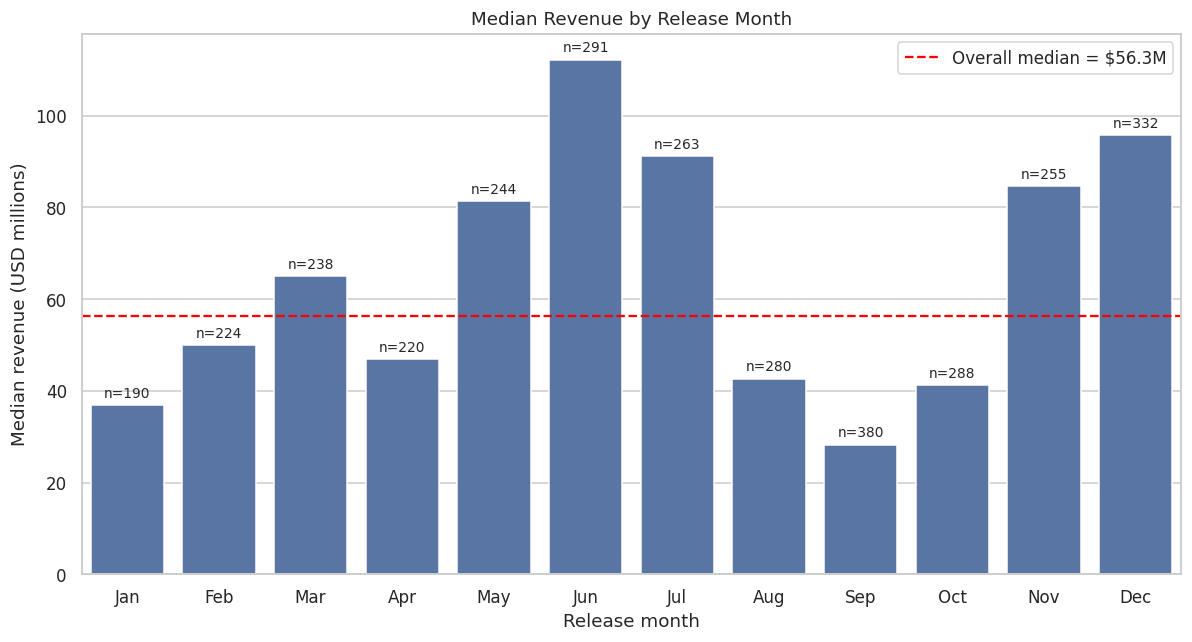

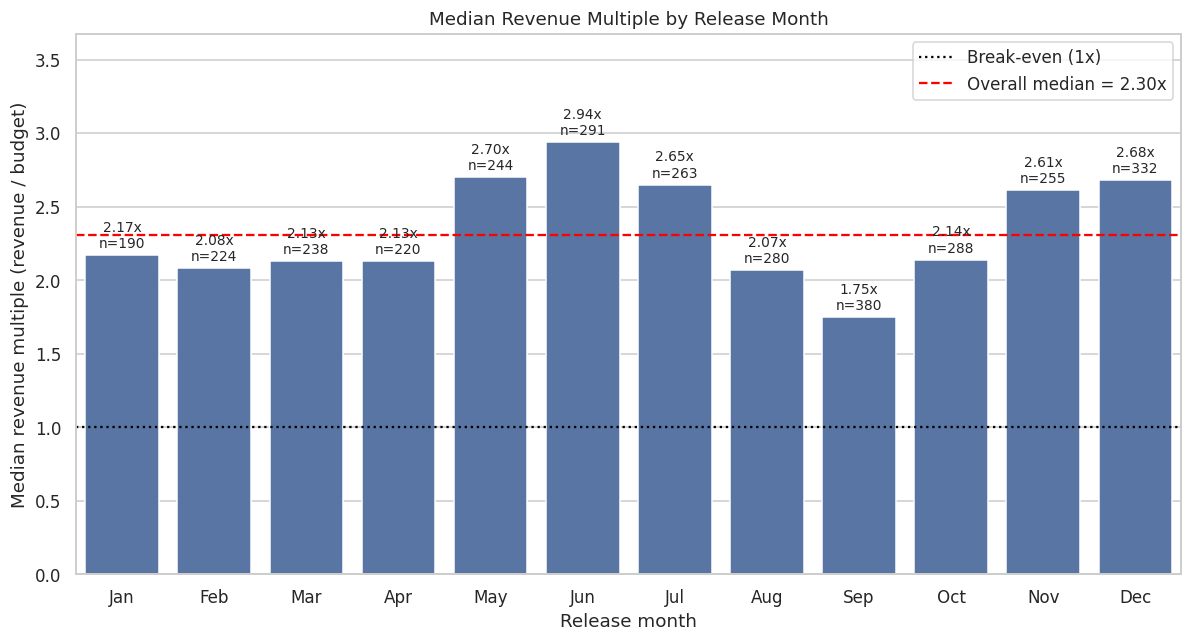

In [16]:
import calendar

fin_m = df_clean[
    df_clean['valid_financial'] & df_clean['release_month'].notna()
].copy()
fin_m['release_month'] = fin_m['release_month'].astype(int)

print(f"Film dianalisis (finansial valid + tanggal rilis ada): {len(fin_m):,}")

# ---------- 1) Ringkasan per bulan ----------
month_summary = (
    fin_m.groupby('release_month')
    .agg(
        films=('title', 'count'),
        median_budget_M=('budget', lambda s: s.median() / 1e6),
        median_revenue_M=('revenue', lambda s: s.median() / 1e6),
        median_multiple=('revenue_multiple', 'median'),
        profit_rate_pct=('profit', lambda s: (s > 0).mean() * 100),
    )
    .round(2)
)
month_summary.index = [calendar.month_abbr[m] for m in month_summary.index]
month_summary.index.name = 'month'
display(month_summary)

overall_rev = fin_m['revenue'].median() / 1e6
overall_mult = fin_m['revenue_multiple'].median()
print(f"\nMedian keseluruhan: revenue = ${overall_rev:.1f}M | multiple = {overall_mult:.2f}x")

plot_df = month_summary.reset_index()
order = plot_df['month'].tolist()

# ---------- 2) Median revenue per bulan (skala) ----------
plt.figure(figsize=(11, 6))
ax = sns.barplot(data=plot_df, x='month', y='median_revenue_M', order=order)
plt.axhline(overall_rev, linestyle='--', color='red', label=f'Overall median = ${overall_rev:.1f}M')
for i, row in plot_df.iterrows():
    ax.text(i, row['median_revenue_M'] + 1, f"n={int(row['films'])}",
            ha='center', va='bottom', fontsize=9)
plt.title('Median Revenue by Release Month')
plt.xlabel('Release month')
plt.ylabel('Median revenue (USD millions)')
plt.legend()
save_show('12_median_revenue_by_month')

# ---------- 3) Median revenue multiple per bulan (efisiensi) ----------
plt.figure(figsize=(11, 6))
ax = sns.barplot(data=plot_df, x='month', y='median_multiple', order=order)
plt.axhline(1, linestyle=':', color='black', label='Break-even (1x)')
plt.axhline(overall_mult, linestyle='--', color='red', label=f'Overall median = {overall_mult:.2f}x')
for i, row in plot_df.iterrows():
    ax.text(i, row['median_multiple'] + 0.03, f"{row['median_multiple']:.2f}x\nn={int(row['films'])}",
            ha='center', va='bottom', fontsize=9)
plt.title('Median Revenue Multiple by Release Month')
plt.xlabel('Release month')
plt.ylabel('Median revenue multiple (revenue / budget)')
plt.ylim(0, plot_df['median_multiple'].max() * 1.25)
plt.legend()
save_show('13_median_multiple_by_month')

Film dianalisis: 3,205


,films,median_budget_M,median_multiple,profit_rate_pct
season,,,,
Summer (May-Jul),798,35.00,2.77,82.33
Holiday (Nov-Dec),587,34.00,2.64,80.24
Other months,1820,22.00,2.04,71.48



Jumlah film per sel


season,Summer (May-Jul),Holiday (Nov-Dec),Other months
budget_group,,,
Q1 (lowest),188,112,527
Q2,142,144,490
Q3,181,136,500
Q4 (highest),287,195,303



Persentase film untung (%)


season,Summer (May-Jul),Holiday (Nov-Dec),Other months
budget_group,,,
Q1 (lowest),78.72,80.36,75.14
Q2,73.24,75.69,67.55
Q3,82.87,80.15,70.40
Q4 (highest),88.85,83.59,73.27



Median revenue multiple


season,Summer (May-Jul),Holiday (Nov-Dec),Other months
budget_group,,,
Q1 (lowest),4.20,3.81,3.30
Q2,2.23,2.67,1.90
Q3,2.51,2.64,1.74
Q4 (highest),2.68,2.26,1.83



Selisih persentase untung terhadap 'Other months' (poin)


,Summer minus Other (pts),Holiday minus Other (pts)
budget_group,,
Q1 (lowest),3.58,5.22
Q2,5.69,8.14
Q3,12.47,9.75
Q4 (highest),15.58,10.32


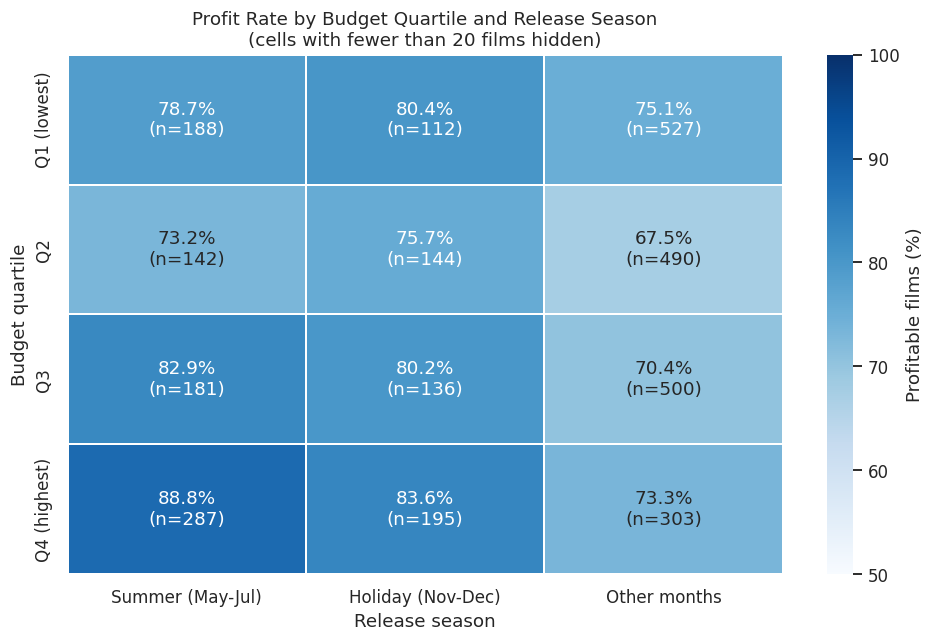

In [17]:
MIN_CELL = 20   # sel dengan film < ini dianggap tidak andal

fin_m = df_clean[
    df_clean['valid_financial'] & df_clean['release_month'].notna()
].copy()
fin_m['release_month'] = fin_m['release_month'].astype(int)

# ---------- 1) Kelompok musim (dibuat SETELAH melihat hasil bulanan -> eksploratif) ----------
def to_season(m):
    if m in (5, 6, 7):
        return 'Summer (May-Jul)'
    if m in (11, 12):
        return 'Holiday (Nov-Dec)'
    return 'Other months'

season_order = ['Summer (May-Jul)', 'Holiday (Nov-Dec)', 'Other months']
fin_m['season'] = pd.Categorical(
    fin_m['release_month'].apply(to_season), categories=season_order, ordered=True
)
fin_m['budget_group'] = pd.qcut(
    fin_m['budget'], 4, labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)']
)

# ---------- 2) Ringkasan per musim ----------
season_summary = (
    fin_m.groupby('season', observed=True)
    .agg(
        films=('title', 'count'),
        median_budget_M=('budget', lambda s: s.median() / 1e6),
        median_multiple=('revenue_multiple', 'median'),
        profit_rate_pct=('profit', lambda s: (s > 0).mean() * 100),
    )
    .round(2)
)
print(f"Film dianalisis: {len(fin_m):,}")
display(season_summary)

# ---------- 3) Ringkasan per kombinasi budget x musim ----------
cell_summary = (
    fin_m.groupby(['budget_group', 'season'], observed=True)
    .agg(
        films=('title', 'count'),
        median_multiple=('revenue_multiple', 'median'),
        profit_rate_pct=('profit', lambda s: (s > 0).mean() * 100),
    )
    .round(2)
)

films_tbl = cell_summary['films'].unstack('season').fillna(0).astype(int)
profit_tbl = cell_summary['profit_rate_pct'].unstack('season')
multiple_tbl = cell_summary['median_multiple'].unstack('season')

print("\nJumlah film per sel")
display(films_tbl)
print("\nPersentase film untung (%)")
display(profit_tbl)
print("\nMedian revenue multiple")
display(multiple_tbl)

gap_tbl = pd.DataFrame({
    'Summer minus Other (pts)': profit_tbl['Summer (May-Jul)'] - profit_tbl['Other months'],
    'Holiday minus Other (pts)': profit_tbl['Holiday (Nov-Dec)'] - profit_tbl['Other months'],
}).round(2)
print("\nSelisih persentase untung terhadap 'Other months' (poin)")
display(gap_tbl)

# ---------- 4) Heatmap persentase film untung ----------
annot = profit_tbl.copy().astype(object)
for r in profit_tbl.index:
    for c in profit_tbl.columns:
        n = films_tbl.loc[r, c]
        annot.loc[r, c] = f"{profit_tbl.loc[r, c]:.1f}%\n(n={n})" if n > 0 else ""

mask = films_tbl < MIN_CELL

plt.figure(figsize=(9, 6))
sns.heatmap(
    profit_tbl.astype(float),
    annot=annot,
    fmt='',
    cmap='Blues',
    vmin=50,
    vmax=100,
    mask=mask,
    linewidths=1,
    cbar_kws={'label': 'Profitable films (%)'},
)
plt.title(f'Profit Rate by Budget Quartile and Release Season\n(cells with fewer than {MIN_CELL} films hidden)')
plt.xlabel('Release season')
plt.ylabel('Budget quartile')
save_show('14_profit_rate_budget_x_season')

### Release Season vs Return

- **Summer and holiday releases outperform other months.** Films released in May-July have a
  median revenue multiple of 2.77x and 82.3% were profitable (n = 798). For November-December
  the figures are 2.64x and 80.2% (n = 587), versus 2.04x and 71.5% for all other months (n = 1,820).
  At the monthly level, June has the highest median multiple (2.94x) and September the lowest
  (1.75x, 65.5% profitable, n = 380).
- **Big-budget films cluster in these windows.** 36.0% of summer releases and 33.2% of holiday
  releases fall in the highest budget quartile, compared with 16.6% of releases in other months.
- **The advantage persists within every budget quartile.** Both the profit rate and the median
  revenue multiple are higher in summer and holiday than in other months in all four quartiles,
  so the seasonal pattern is not just a budget effect.
- **The gap grows with budget.** The profit-rate advantage of summer over other months rises from
  3.6 points in the lowest budget quartile to 15.6 points in the highest (holiday: 5.2 to 10.3).

> Season groups were defined after inspecting the monthly results, so this analysis is exploratory.
> Differences in the lowest budget quartile (112 to 188 films per cell) are small and may reflect
> sampling variation, and the top quartile spans a wide budget range ($56M to $380M), so some
> confounding remains. The dataset does not state whether release dates are US or worldwide, and
> no statistical test was run.

In [18]:
import os

MIN_VOTES = 10

fin = df_clean[df_clean['valid_financial']]
both_present = df_clean['budget'].notna() & df_clean['revenue'].notna()

# ---------- 1) Cakupan data ----------
n_total = len(df_clean)
n_valid = len(fin)
n_missing = int((~both_present).sum())
n_threshold = int((both_present & ~df_clean['valid_financial']).sum())

print("=== COVERAGE ===")
print(f"Total films                              : {n_total:,}")
print(f"Valid financial data                     : {n_valid:,} ({n_valid / n_total * 100:.1f}%)")
print(f"Excluded: budget or revenue missing (0)  : {n_missing:,}")
print(f"Excluded: implausibly low budget/revenue : {n_threshold:,}")
print(f"Check (jumlah sama dengan total)         : {n_valid + n_missing + n_threshold == n_total}")

# ---------- 2) Metrik utama (film dengan data finansial valid) ----------
print("\n=== HEADLINE METRICS (valid financial films) ===")
print(f"Profitable films         : {(fin['profit'] > 0).mean() * 100:.2f}%")
print(f"Median revenue multiple  : {fin['revenue_multiple'].median():.2f}x")
print(f"Share below break-even   : {(fin['revenue_multiple'] < 1).mean() * 100:.1f}%")
print(f"Median budget            : ${fin['budget'].median() / 1e6:.1f}M")
print(f"Median revenue           : ${fin['revenue'].median() / 1e6:.1f}M")
print(f"Median profit            : ${fin['profit'].median() / 1e6:.1f}M")
print(f"Release years covered    : {int(df_clean['release_year'].min())} - {int(df_clean['release_year'].max())}")

# ---------- 3) Sampel rating ----------
rated_all = df_clean[df_clean['vote_count'] >= MIN_VOTES]
rated_fin = fin[fin['vote_count'] >= MIN_VOTES]

print(f"\n=== RATING SAMPLE (>= {MIN_VOTES} votes) ===")
print(f"All films                : {len(rated_all):,}")
print(f"With valid financials    : {len(rated_fin):,}")
print(f"Median rating (all rated): {rated_all['vote_average'].median():.2f}")

# ---------- 4) Grafik yang tersimpan ----------
print("\n=== SAVED CHARTS ===")
files_saved = sorted(os.listdir('images'))
for f in files_saved:
    print(f)
print(f"Total: {len(files_saved)} file (harapan: 14)")

=== COVERAGE ===
Total films                              : 4,803
Valid financial data                     : 3,205 (66.7%)
Excluded: budget or revenue missing (0)  : 1,574
Excluded: implausibly low budget/revenue : 24
Check (jumlah sama dengan total)         : True

=== HEADLINE METRICS (valid financial films) ===
Profitable films         : 75.79%
Median revenue multiple  : 2.30x
Share below break-even   : 24.2%
Median budget            : $25.5M
Median revenue           : $56.3M
Median profit            : $27.1M
Release years covered    : 1916 - 2017

=== RATING SAMPLE (>= 10 votes) ===
All films                : 4,392
With valid financials    : 3,166
Median rating (all rated): 6.30

=== SAVED CHARTS ===
01_rating_distribution.png
02_popularity_distribution.png
03_budget_distribution.png
04_revenue_multiple_distribution.png
05_budget_vs_multiple.png
06_profit_rate_by_budget_group.png
07_multiple_by_genre.png
08_profit_rate_by_genre.png
09_rating_vs_multiple.png
10_profit_rate_by_rating

## Conclusions and Business Recommendations

**Answer to the business question.** Across 3,205 films with valid financial data, 75.79% earned
back their budget and the median revenue multiple was 2.30x. What separates profitable from
unprofitable films is less about spending more and more about *how* the money is deployed:
budget buys scale, audience reception and release timing are associated with efficiency, and
genre points to two distinct routes to profit.

### Implications (descriptive, not causal)

1. **Choose the objective before the budget.** Larger budgets are associated with larger absolute
   profit (median $8.5M in the lowest quartile vs $112.3M in the highest) and lower loss risk
   (81.5% profitable in the top quartile), but not with better return per dollar (median
   multiple 3.57x vs 2.22x). A studio maximizing absolute profit and one maximizing return per
   dollar would read the same data differently.
2. **Genre offers two routes to profit.** Horror combines a low median budget ($14M) with the
   highest profit rate (82.1%). Animation combines the largest median budget ($75M) with the
   highest median profit ($126.8M). Drama, History and Western sit at the lower end
   (about 70% to 71% profitable).
3. **Release timing matters most for big-budget films.** Summer (May-Jul) and holiday (Nov-Dec)
   releases are more often profitable than other months in every budget quartile, and the gap
   grows with budget (15.6 points for summer in the top quartile). September is the weakest
   month (1.75x median multiple, 65.5% profitable).
4. **Quality risk is highest for expensive films.** In the two highest budget quartiles, the median
   film rated below 5.0 did not recover its budget (0.74x and 0.79x). Ratings arrive after release,
   so they cannot be used to select films in advance, but the pattern suggests that spending on
   development and quality control is most valuable where the downside is largest. This last
   point is an interpretation, not a tested result.

### Possible next steps
- Add a dashboard (Looker Studio or Power BI) for the headline metrics.
- Adjust budget and revenue for inflation and compare across decades.
- Test the seasonal and genre differences with formal statistical tests.

## Limitations

- **Coverage.** Only 3,205 of 4,803 films (66.7%) have usable financial data: 1,574 have a missing
  budget or revenue (recorded as 0) and 24 were excluded for implausibly low values
  (budget or revenue below $10,000). Films with recorded financials may differ systematically
  from those without, so results may not generalize to all films.
- **Threshold choice.** The $10,000 cut-off was chosen after inspecting the data. A robustness
  check on 23 films with unusually low revenue but budgets of $1M or more showed almost no
  change (profit rate 75.79% to 76.34%, median multiple 2.30x to 2.32x), so they were retained.
- **Nominal dollars.** Budget and revenue are not adjusted for inflation, and the data spans
  1916 to 2017, so comparisons across decades are biased.
- **Unclear definitions.** The dataset does not state whether revenue includes home video or
  streaming, or whether release dates are US or worldwide releases.
- **Association, not causation.** Ratings are given after release and may reflect audience reach.
  Budget was controlled for using four quartile groups only, which is a coarse check, and other
  confounders (such as genre and release year) were not controlled at the same time.
- **Overlapping genres and small samples.** A film can belong to several genres, so genre counts
  are not additive. Documentary (n = 37) and Western (n = 57) are small samples.
- **Exploratory season groups.** Seasons were defined after inspecting monthly results, and no
  statistical tests were run, so small differences should not be read as firm rankings.

In [20]:
import shutil
from google.colab import files

shutil.make_archive('images', 'zip', 'images')   # membuat images.zip
files.download('images.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>